# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df = pd.read_csv("synthetic_premium_dataset.csv")
df

,age,monthly_income,website_visits,time_spent_minutes,previous_purchases,is_student,country,device_type,purchased
0,56,1638.553977,8,16.728722,1,0,TR,Desktop,1
1,46,2499.096428,6,13.626011,2,0,NL,Tablet,1
2,32,3727.544600,9,6.122760,2,0,NL,Mobile,0
3,60,4867.453423,10,9.321937,5,1,NL,Mobile,1
4,25,2703.895072,12,12.331889,6,0,TR,Mobile,1
...,...,...,...,...,...,...,...,...,...
9995,33,6017.579566,6,9.049433,5,0,NL,Desktop,0
9996,29,5263.230651,6,20.253556,2,0,NL,Mobile,1
9997,18,4185.740620,7,17.508512,5,1,DE,Mobile,1
9998,25,1911.611069,11,10.865050,4,1,TR,Mobile,0


# Dataset Overview

In [3]:
df.sample(12)

,age,monthly_income,website_visits,time_spent_minutes,previous_purchases,is_student,country,device_type,purchased
1846,39,4497.677202,13,16.219007,4,1,FR,Mobile,0
2200,61,3815.335205,16,18.705167,0,0,DE,Desktop,1
6153,44,3926.506448,10,12.926595,4,0,NL,Desktop,1
1613,59,5486.438973,12,11.921584,1,0,DE,Tablet,1
1730,53,3711.400620,10,9.506671,3,0,DE,Mobile,1
6857,46,3030.207670,12,10.576371,2,0,NL,Tablet,1
3468,40,5294.818934,12,7.568482,1,1,DE,Tablet,1
1277,54,1000.000000,8,21.706966,2,1,NL,Mobile,1
4490,51,6145.933309,10,11.324991,2,1,NL,Mobile,0
1859,27,5937.517542,13,11.647766,4,1,TR,Tablet,1


In [4]:
df.describe()

,age,monthly_income,website_visits,time_spent_minutes,previous_purchases,is_student,purchased
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.054000,4011.548809,10.038500,15.031669,3.009900,0.296900,0.793200
std,13.484104,1467.782573,3.197912,5.010769,1.723281,0.456915,0.405031
min,18.000000,1000.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,2974.139231,8.000000,11.700613,2.000000,0.000000,1.000000
50%,41.000000,3996.377858,10.000000,15.018620,3.000000,0.000000,1.000000
75%,53.000000,5005.978546,12.000000,18.364640,4.000000,1.000000,1.000000
max,64.000000,9399.200171,27.000000,32.871504,10.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 10000 non-null  int64  
 1   monthly_income      10000 non-null  float64
 2   website_visits      10000 non-null  int64  
 3   time_spent_minutes  10000 non-null  float64
 4   previous_purchases  10000 non-null  int64  
 5   is_student          10000 non-null  int64  
 6   country             10000 non-null  object 
 7   device_type         10000 non-null  object 
 8   purchased           10000 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


In [6]:
df.describe(include=object)

,country,device_type
count,10000,10000
unique,4,3
top,DE,Mobile
freq,2563,3376


# Data Cleaning

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

age                   0
monthly_income        0
website_visits        0
time_spent_minutes    0
previous_purchases    0
is_student            0
country               0
device_type           0
purchased             0
dtype: int64

# Encoding Categorical Features - OHE

In [9]:
df["device_type"].unique()

array(['Desktop', 'Tablet', 'Mobile'], dtype=object)

In [10]:
df["country"].unique()

array(['TR', 'NL', 'FR', 'DE'], dtype=object)

In [11]:
df = pd.get_dummies(df, columns=['country', 'device_type'], drop_first=True)

# Feature & Target Selection

In [12]:
X = df.drop(columns=["purchased"])
y = df["purchased"]

# Train Test Split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)
X_train,X_test,y_train,y_test

(      age  monthly_income  website_visits  time_spent_minutes  \
 2967   31     5884.920404              17           14.970366   
 700    34     5119.260457              13           23.715132   
 3481   61     4483.948477               4           23.662766   
 1621   41     4468.494373               9           11.565577   
 800    32     4481.139787               9           27.207913   
 ...   ...             ...             ...                 ...   
 9225   61     4561.630977              12           16.080786   
 4859   45     6590.988544              19           18.216513   
 3264   19     4362.400785              15           17.063836   
 9845   64     6429.974296              15            4.878992   
 2732   42     6255.934800              13           16.631943   
 
       previous_purchases  is_student  country_FR  country_NL  country_TR  \
 2967                   3           0       False       False       False   
 700                    4           1       False   

# Feature Scaling

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

In [15]:
lr = LogisticRegression()

In [16]:
lr.fit(X_train,y_train)

LogisticRegression()

In [17]:
lr.coef_

array([[-0.00701184,  0.07028541,  0.18303336,  0.17628051,  0.10876501,
        -0.10538655, -0.01802904, -0.06931192, -0.03465336, -0.01875107,
        -0.05242045]])

In [18]:
lr.intercept_

array([1.38858752])

# Prediction

In [19]:
y_pred = lr.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

# Model Evaluation

In [20]:
confusion_matrix(y_test,y_pred)

array([[   0,  537],
       [   0, 1963]])

<Axes: >

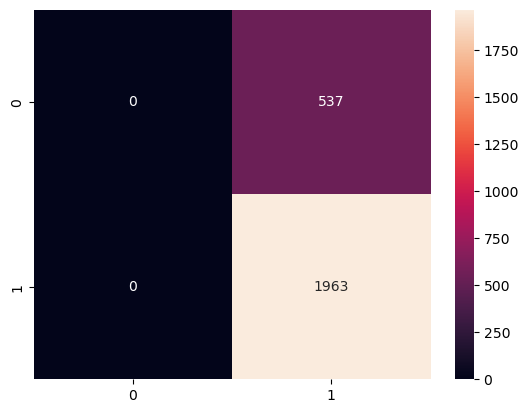

In [21]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='g')

In [22]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       537
           1       0.79      1.00      0.88      1963

    accuracy                           0.79      2500
   macro avg       0.39      0.50      0.44      2500
weighted avg       0.62      0.79      0.69      2500



In [23]:
accuracy_score(y_test,y_pred)

0.7852

In [24]:
print(f'accuracy of the model :',round(accuracy_score(y_test,y_pred)*100,2))

accuracy of the model : 78.52


# Conclusion

- The Logistic Regression model achieved an accuracy of **78.52%** on the synthetic premium prediction dataset.  
- The model successfully identified most purchased users but showed lower performance for non-purchased cases due to class imbalance.  
- Applying techniques such as SMOTE, class balancing, and advanced machine learning models could further improve prediction performance.